# Persona-Based Extreme Evaluation: GNN+EBM Pipeline vs MILP

Evaluates the pipeline on **3 persona-based extreme-criticality families** (100 scenarios each).
Each persona weights criticality drivers differently:

| Persona | Key Drivers | α | Philosophy |
|---------|-------------|---|------------|
| **VRE/Battery Developer** | A1, A2, A4, A7, A8, B8 | 0.55 | High VRE, storage stress, SOC coupling |
| **Network Operator** | A2, A3, A5, A9, A11, A12, B1, B6, B9, B10 | 0.50 | Large network, congestion, trade |
| **Mathematician** | B1-B10 (all), A5, A9 | 0.20 | Pure combinatorial MILP hardness |

**Prerequisites:**
- Run `python -m scripts.generate_persona_scenarios` locally
- Upload all 3 `outputs/persona_*_scenarios/` folders to Google Drive
- Models: `best_encoder.pt`, `ebm_v3_final.pt`

## 1. Install Dependencies

In [1]:
import subprocess, sys

print('Installing PyTorch 2.5.1 and PyTorch Geometric...')

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'torch-scatter', 'torch-sparse', 'torch-geometric'],
    capture_output=True)

!pip install -q torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu124.html
!pip install -q torch-geometric
!pip install -q numpy scipy tqdm pandas matplotlib seaborn scikit-learn pyomo highspy thrml

print('Dependencies installed')

Installing PyTorch 2.5.1 and PyTorch Geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 150.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 73.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 116.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 156.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.

## 2. Mount Drive & Setup

In [3]:
import importlib, sys

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f'Cleared {len(modules_to_clear)} cached modules')

Cleared 0 cached modules


In [4]:
import os, sys, json, time, pickle, shutil, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Any
from tqdm.auto import tqdm
from collections import Counter
from dataclasses import asdict
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

REPO_PATH = Path('/content/drive/MyDrive/benchmark')
sys.path.insert(0, str(REPO_PATH))
os.chdir(REPO_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Repo: {REPO_PATH}')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Mounted at /content/drive
Repo: /content/drive/MyDrive/benchmark
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [5]:
pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f'Purged {len(pycache_dirs)} __pycache__ directories')

# Verify critical fixes
lp_src = (REPO_PATH / 'src/milp/lp_worker_two_stage.py').read_text(encoding='utf-8')
assert 'import_mode[t].fix(1.0)' not in lp_src, 'BUG: old import_mode fix still present!'
feas_src = (REPO_PATH / 'src/ebm/feasibility.py').read_text(encoding='utf-8')
assert 'ebm_therm = u_relax' in feas_src, 'BUG: decoder v5 EBM-guided fix missing!'
runner_src = (REPO_PATH / 'src/eval/pipeline_runner.py').read_text(encoding='utf-8')
assert "init_mode='bernoulli'" in runner_src, 'BUG: sampler init_mode fix missing!'
print('All fixes verified')

Purged 9 __pycache__ directories
All fixes verified


## 3. Configuration

In [6]:
PERSONA_CONFIG = {
    'vre_battery': {
        'label': 'VRE / Battery Developer',
        'dir': 'persona_vre_battery_scenarios',
        'color': '#f39c12',
        'alpha': 0.55,
    },
    'network_operator': {
        'label': 'Network Operator',
        'dir': 'persona_network_operator_scenarios',
        'color': '#3498db',
        'alpha': 0.50,
    },
    'mathematician': {
        'label': 'Mathematician',
        'dir': 'persona_mathematician_scenarios',
        'color': '#9b59b6',
        'alpha': 0.20,
    },
}

OUTPUT_DIR = REPO_PATH / 'outputs/pipeline_eval_personas'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Check what's available
for pkey, pcfg in PERSONA_CONFIG.items():
    pdir = REPO_PATH / 'outputs' / pcfg['dir']
    sc_count = len(list(pdir.glob('scenario_*.json'))) if pdir.exists() else 0
    rp_count = len(list((pdir / 'reports').glob('scenario_*.json'))) if (pdir / 'reports').exists() else 0
    print(f'{pcfg["label"]:35s}: {sc_count} scenarios, {rp_count} reports')

VRE / Battery Developer            : 100 scenarios, 100 reports
Network Operator                   : 100 scenarios, 100 reports
Mathematician                      : 100 scenarios, 100 reports


## 4. Solve All Personas with MILP

In [7]:
from src.milp.solve import solve_scenario
from src.milp.batch_runner import _serialize_report

TIME_LIMIT = 1200.0

for pkey, pcfg in PERSONA_CONFIG.items():
    pdir = REPO_PATH / 'outputs' / pcfg['dir']
    reports_dir = pdir / 'reports'
    reports_dir.mkdir(parents=True, exist_ok=True)

    scenario_files = sorted(pdir.glob('scenario_*.json'))
    already_solved = len(list(reports_dir.glob('scenario_*.json')))
    remaining = len(scenario_files) - already_solved

    print(f'\n{"="*60}')
    print(f'MILP SOLVE: {pcfg["label"]} ({remaining} remaining / {len(scenario_files)} total)')
    print(f'{"="*60}')

    if remaining == 0:
        print('  All scenarios already solved - skipping')
        continue

    for sc_path in tqdm(scenario_files, desc=f'MILP [{pkey}]'):
        sc_id = sc_path.stem
        report_path = reports_dir / f'{sc_id}.json'
        if report_path.exists():
            continue
        try:
            report = solve_scenario(
                sc_path, solver_name='highs', tee=False,
                capture_detail=True, time_limit_seconds=TIME_LIMIT,
            )
            serialized = _serialize_report(report)
            with open(report_path, 'w', encoding='utf-8') as f:
                json.dump(serialized, f, indent=2)
        except Exception as e:
            tqdm.write(f'  {sc_id}: FAILED - {e}')

    # Report termination distribution
    terms = []
    for rp in reports_dir.glob('scenario_*.json'):
        with open(rp) as f:
            d = json.load(f)
        terms.append(d.get('mip', {}).get('termination_condition', 'unknown'))
    print(f'  Termination: {dict(Counter(terms))}')


MILP SOLVE: VRE / Battery Developer (0 remaining / 100 total)
  All scenarios already solved - skipping

MILP SOLVE: Network Operator (0 remaining / 100 total)
  All scenarios already solved - skipping

MILP SOLVE: Mathematician (0 remaining / 100 total)
  All scenarios already solved - skipping


## 5. Run Pipeline on All Personas

In [8]:
from src.eval.pipeline_runner import PipelineConfig, PipelineRunner

config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    solver_name='appsi_highs',
    device=DEVICE,
    seed=42,
)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

runner = PipelineRunner(config)
runner.load_models()

Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)


In [9]:
all_results = {}

for pkey, pcfg in PERSONA_CONFIG.items():
    pdir = REPO_PATH / 'outputs' / pcfg['dir']
    reports_dir = pdir / 'reports'
    graphs_dir = OUTPUT_DIR / 'graphs' / pkey

    # Clear stale graph cache
    if graphs_dir.exists():
        shutil.rmtree(graphs_dir)

    print(f'\n{"="*60}')
    print(f'PIPELINE: {pcfg["label"]}')
    print(f'{"="*60}')

    results = runner.evaluate_family(
        scenarios_dir=pdir,
        reports_dir=reports_dir,
        graphs_dir=graphs_dir,
        family_name=pkey,
    )

    pkl_path = OUTPUT_DIR / f'pipeline_eval_{pkey}.pkl'
    runner.save_results(results, pkl_path)
    all_results[pkey] = results
    print(f'  Saved {len(results)} results to {pkl_path}')


PIPELINE: VRE / Battery Developer

Evaluating 100 scenarios from vre_battery


Pipeline [vre_battery]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_vre_battery.pkl
  Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_vre_battery.pkl

PIPELINE: Network Operator

Evaluating 100 scenarios from network_operator


Pipeline [network_operator]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_network_operator.pkl
  Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_network_operator.pkl

PIPELINE: Mathematician

Evaluating 100 scenarios from mathematician


Pipeline [mathematician]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_mathematician.pkl
  Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_personas/pipeline_eval_mathematician.pkl


## 6. Build Comparison DataFrames

In [10]:
from src.eval.metrics import compute_eval_metrics, format_metrics_table

persona_dfs = {}

for pkey, pcfg in PERSONA_CONFIG.items():
    pdir = REPO_PATH / 'outputs' / pcfg['dir']
    reports_dir = pdir / 'reports'

    pkl_path = OUTPUT_DIR / f'pipeline_eval_{pkey}.pkl'
    if pkl_path.exists():
        pipeline_results = PipelineRunner.load_results(pkl_path)
    else:
        pipeline_results = [asdict(r) for r in all_results[pkey]]

    eval_output = compute_eval_metrics(pipeline_results, {pkey: reports_dir})
    df_p = eval_output['dataframe']
    df_p['persona'] = pkey
    persona_dfs[pkey] = df_p

    n_tl = (df_p['milp_termination'] == 'maxTimeLimit').sum()
    print(f'{pcfg["label"]:35s}: {len(df_p)} scenarios, '
          f'MaxTimeLimit={n_tl} ({n_tl/max(len(df_p),1)*100:.0f}%)')

# Combined DataFrame
df = pd.concat(persona_dfs.values(), ignore_index=True)
print(f'\nTotal: {len(df)} scenarios across {len(persona_dfs)} personas')

VRE / Battery Developer            : 100 scenarios, MaxTimeLimit=0 (0%)
Network Operator                   : 100 scenarios, MaxTimeLimit=49 (49%)
Mathematician                      : 100 scenarios, MaxTimeLimit=28 (28%)

Total: 300 scenarios across 3 personas


## 7. Per-Persona P90-P99 Metrics

In [11]:
for pkey, pcfg in PERSONA_CONFIG.items():
    df_p = persona_dfs[pkey]
    valid = df_p.dropna(subset=['speedup', 'cost_gap_pct'])
    n_better = (valid['cost_gap_pct'] < 0).sum()
    n_tl = (df_p['milp_termination'] == 'maxTimeLimit').sum()

    print(f'\n{"="*70}')
    print(f'{pcfg["label"].upper()} (n={len(df_p)}, MaxTimeLimit={n_tl})')
    print(f'{"="*70}')
    print(f'  Pipeline time: mean={df_p["pipeline_solve_time"].mean():.1f}s, '
          f'median={df_p["pipeline_solve_time"].median():.1f}s')
    print(f'  MILP time:     mean={df_p["milp_solve_time"].mean():.1f}s, '
          f'median={df_p["milp_solve_time"].median():.1f}s')
    print(f'  Speedup:       mean={valid["speedup"].mean():.1f}x, '
          f'median={valid["speedup"].median():.1f}x')
    print(f'  Cost gap:      P50={valid["cost_gap_pct"].median():.1f}%, '
          f'P90={np.percentile(valid["cost_gap_pct"], 90):.1f}%')
    print(f'  Pipeline better: {n_better}/{len(valid)} ({n_better/max(len(valid),1)*100:.0f}%)')
    print(f'  Stage dist: {dict(df_p["pipeline_stage"].value_counts())}')


VRE / BATTERY DEVELOPER (n=100, MaxTimeLimit=0)
  Pipeline time: mean=155.0s, median=129.2s
  MILP time:     mean=24.3s, median=16.6s
  Speedup:       mean=0.2x, median=0.1x
  Cost gap:      P50=4.7%, P90=31.8%
  Pipeline better: 22/100 (22%)
  Stage dist: {'repair_20': np.int64(49), 'full_soft': np.int64(34), 'hard_fix': np.int64(17)}

NETWORK OPERATOR (n=100, MaxTimeLimit=49)
  Pipeline time: mean=186.4s, median=151.7s
  MILP time:     mean=703.6s, median=1148.1s
  Speedup:       mean=5.5x, median=4.3x
  Cost gap:      P50=30.0%, P90=148.3%
  Pipeline better: 31/100 (31%)
  Stage dist: {'hard_fix': np.int64(36), 'repair_20': np.int64(33), 'full_soft': np.int64(31)}

MATHEMATICIAN (n=100, MaxTimeLimit=28)
  Pipeline time: mean=318.3s, median=356.8s
  MILP time:     mean=364.4s, median=36.0s
  Speedup:       mean=2.6x, median=0.1x
  Cost gap:      P50=-100.6%, P90=103.4%
  Pipeline better: 76/100 (76%)
  Stage dist: {'full_soft': np.int64(77), 'hard_fix': np.int64(15), 'repair_20': np

## 8. Cross-Persona Comparison Dashboard

/tmp/ipykernel_961/3193753389.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_time, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],
/tmp/ipykernel_961/3193753389.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_gap, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],
/tmp/ipykernel_961/3193753389.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_sp, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],


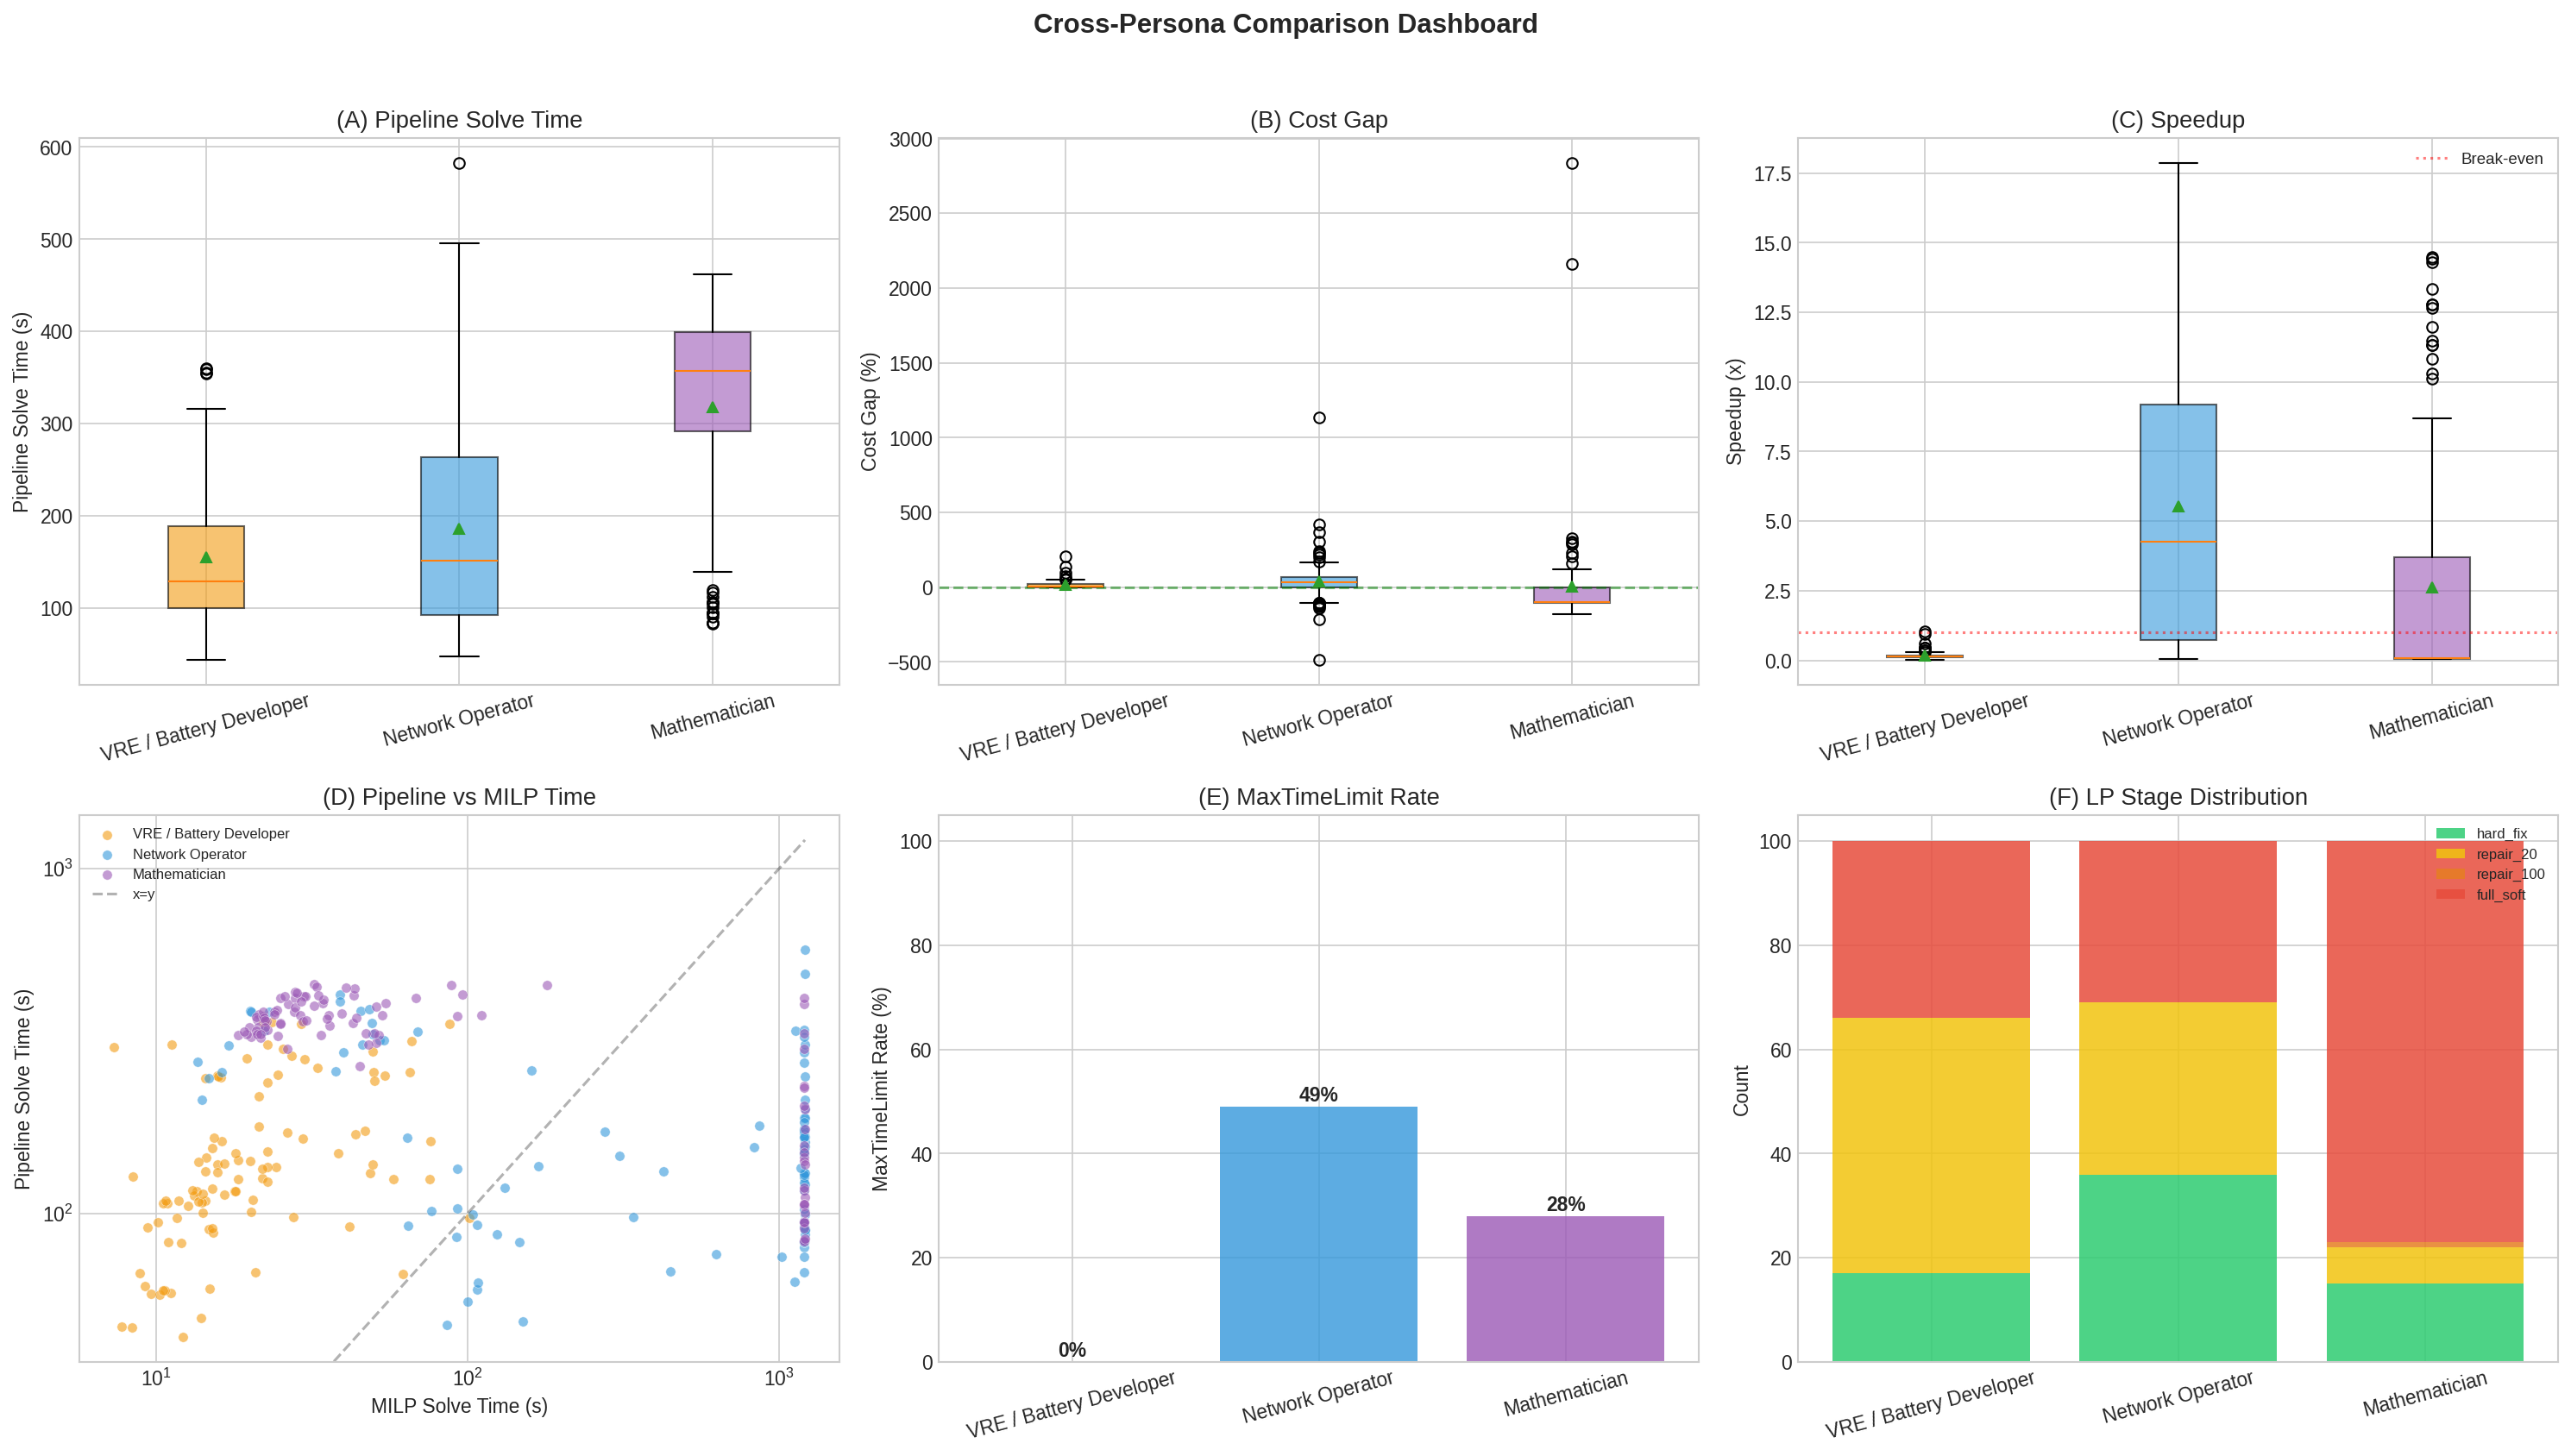

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# Row 1: Solve time, Cost gap, Speedup per persona
# Panel (0,0): Solve time boxplot
ax = axes[0, 0]
data_time = [persona_dfs[pk]['pipeline_solve_time'] for pk in PERSONA_CONFIG]
bp = ax.boxplot(data_time, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],
                patch_artist=True, showmeans=True)
for patch, pk in zip(bp['boxes'], PERSONA_CONFIG):
    patch.set_facecolor(PERSONA_CONFIG[pk]['color'])
    patch.set_alpha(0.6)
ax.set_ylabel('Pipeline Solve Time (s)')
ax.set_title('(A) Pipeline Solve Time')
ax.tick_params(axis='x', rotation=15)

# Panel (0,1): Cost gap boxplot
ax = axes[0, 1]
data_gap = [persona_dfs[pk]['cost_gap_pct'].dropna() for pk in PERSONA_CONFIG]
bp = ax.boxplot(data_gap, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],
                patch_artist=True, showmeans=True)
for patch, pk in zip(bp['boxes'], PERSONA_CONFIG):
    patch.set_facecolor(PERSONA_CONFIG[pk]['color'])
    patch.set_alpha(0.6)
ax.axhline(y=0, color='green', linestyle='--', alpha=0.5)
ax.set_ylabel('Cost Gap (%)')
ax.set_title('(B) Cost Gap')
ax.tick_params(axis='x', rotation=15)

# Panel (0,2): Speedup boxplot
ax = axes[0, 2]
data_sp = [persona_dfs[pk]['speedup'].dropna() for pk in PERSONA_CONFIG]
bp = ax.boxplot(data_sp, labels=[PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG],
                patch_artist=True, showmeans=True)
for patch, pk in zip(bp['boxes'], PERSONA_CONFIG):
    patch.set_facecolor(PERSONA_CONFIG[pk]['color'])
    patch.set_alpha(0.6)
ax.axhline(y=1, color='red', linestyle=':', alpha=0.5, label='Break-even')
ax.set_ylabel('Speedup (x)')
ax.set_title('(C) Speedup')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)

# Panel (1,0): Solve time scatter (all personas)
ax = axes[1, 0]
for pk, pcfg in PERSONA_CONFIG.items():
    df_p = persona_dfs[pk]
    ax.scatter(df_p['milp_solve_time'], df_p['pipeline_solve_time'],
              c=pcfg['color'], label=pcfg['label'], s=30, alpha=0.6,
              edgecolors='white', linewidth=0.3)
ax.plot([0, df['milp_solve_time'].max()], [0, df['milp_solve_time'].max()],
        'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Solve Time (s)')
ax.set_ylabel('Pipeline Solve Time (s)')
ax.set_title('(D) Pipeline vs MILP Time')
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=8)

# Panel (1,1): MaxTimeLimit rate bar chart
ax = axes[1, 1]
pkeys = list(PERSONA_CONFIG.keys())
tl_rates = []
for pk in pkeys:
    df_p = persona_dfs[pk]
    tl_rates.append((df_p['milp_termination'] == 'maxTimeLimit').mean() * 100)
bars = ax.bar([PERSONA_CONFIG[pk]['label'] for pk in pkeys], tl_rates,
              color=[PERSONA_CONFIG[pk]['color'] for pk in pkeys], alpha=0.8)
for bar, rate in zip(bars, tl_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', fontweight='bold')
ax.set_ylabel('MaxTimeLimit Rate (%)')
ax.set_title('(E) MaxTimeLimit Rate')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=15)

# Panel (1,2): Stage distribution stacked bar
ax = axes[1, 2]
stage_order = ['hard_fix', 'repair_20', 'repair_100', 'full_soft']
stage_colors = {'hard_fix': '#2ecc71', 'repair_20': '#f1c40f',
                'repair_100': '#e67e22', 'full_soft': '#e74c3c'}
bottom = np.zeros(len(pkeys))
for stage in stage_order:
    vals = []
    for pk in pkeys:
        df_p = persona_dfs[pk]
        vals.append((df_p['pipeline_stage'] == stage).sum())
    ax.bar([PERSONA_CONFIG[pk]['label'] for pk in pkeys], vals,
           bottom=bottom, color=stage_colors.get(stage, 'gray'),
           label=stage, alpha=0.85)
    bottom += np.array(vals)
ax.set_ylabel('Count')
ax.set_title('(F) LP Stage Distribution')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=15)

fig.suptitle('Cross-Persona Comparison Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_persona_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Criticality Decomposition per Persona

In [13]:
from src.analysis.criticality_index import compute_criticality

stress_labels = [
    'A1 VRE Pen.', 'A2 Resid. Vol.', 'A3 Peak/Valley', 'A4 ST Var.',
    'A5 Demand Scale', 'A6 Peak/Firm', 'A7 Inv Stor P', 'A8 Inv Stor E',
    'A9 Inv Therm Flex', 'A10 Inv DR', 'A11 Trade Rel.', 'A12 Inv Cong.',
]
hardness_labels = [
    'B1 Zones', 'B2 Horizon', 'B3 Binaries', 'B4 Therm Dens.',
    'B5 MinGen Tight', 'B6 Startup Int.', 'B7 Ramp Tight.',
    'B8 SOC Tight.', 'B9 Interconn.', 'B10 Net Hetero.',
]
all_labels = stress_labels + hardness_labels

persona_crit_dfs = {}

for pkey, pcfg in PERSONA_CONFIG.items():
    pdir = REPO_PATH / 'outputs' / pcfg['dir']
    records = []
    for sc_path in sorted(pdir.glob('scenario_*.json')):
        with open(sc_path, 'r', encoding='utf-8') as f:
            scenario = json.load(f)
        result = compute_criticality(scenario, alpha=0.5)  # uniform weights for comparison
        rec = {
            'scenario_id': sc_path.stem,
            'criticality_index': result.criticality_index,
            'stress_index': result.stress_index,
            'hardness_index': result.hardness_index,
            **{f'{k}_norm': v for k, v in result.stress_normalized.items()},
            **{f'{k}_norm': v for k, v in result.hardness_normalized.items()},
        }
        records.append(rec)
    df_c = pd.DataFrame(records)
    persona_crit_dfs[pkey] = df_c
    print(f'{pcfg["label"]:35s}: crit={df_c["criticality_index"].mean():.3f}, '
          f'stress={df_c["stress_index"].mean():.3f}, '
          f'hardness={df_c["hardness_index"].mean():.3f}')

# Identify norm columns
sample_cols = persona_crit_dfs[list(PERSONA_CONFIG.keys())[0]].columns
stress_norm_cols = sorted([c for c in sample_cols if c.startswith('A') and c.endswith('_norm')],
                          key=lambda c: int(c.split('_')[0][1:]))
hardness_norm_cols = sorted([c for c in sample_cols if c.startswith('B') and c.endswith('_norm')],
                            key=lambda c: int(c.split('_')[0][1:]))
all_norm_cols = stress_norm_cols + hardness_norm_cols

VRE / Battery Developer            : crit=0.454, stress=0.652, hardness=0.257
Network Operator                   : crit=0.494, stress=0.677, hardness=0.312
Mathematician                      : crit=0.500, stress=0.590, hardness=0.410


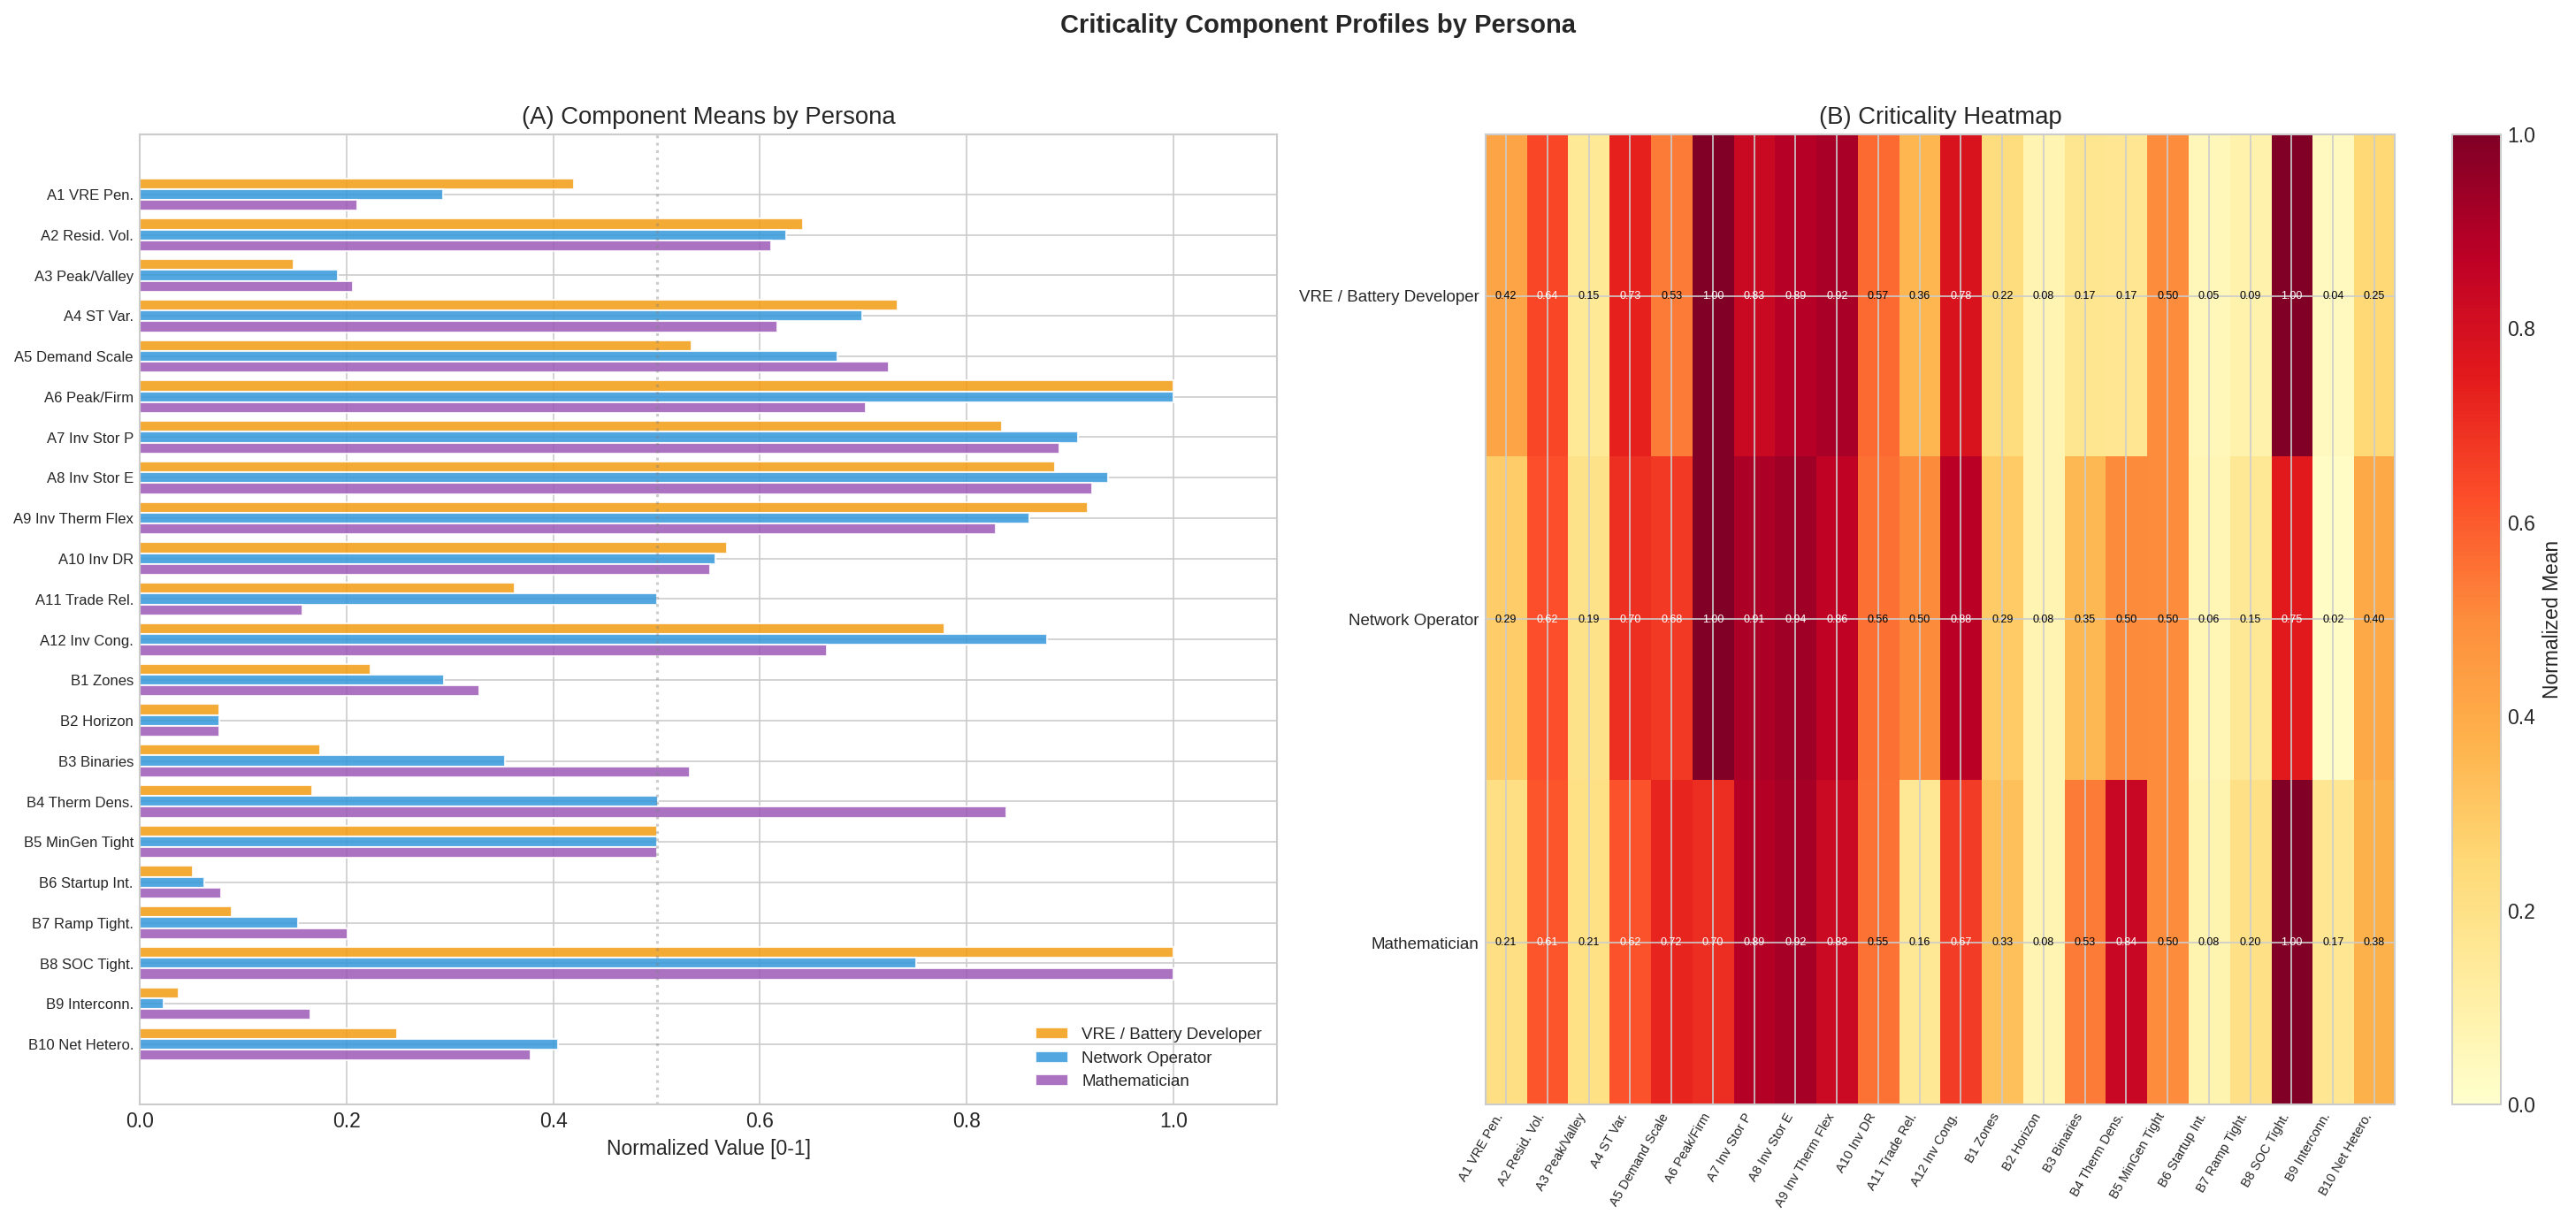

In [14]:
# Side-by-side component comparison (3 personas on same chart)
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

n_comp = len(all_norm_cols)
y_pos = np.arange(n_comp)
n_personas = len(PERSONA_CONFIG)
bar_h = 0.8 / n_personas

# Panel A: Side-by-side bars
ax = axes[0]
for i, (pk, pcfg) in enumerate(PERSONA_CONFIG.items()):
    means = [persona_crit_dfs[pk][c].mean() for c in all_norm_cols]
    ax.barh(y_pos + i * bar_h - 0.4 + bar_h/2, means, bar_h,
            label=pcfg['label'], color=pcfg['color'], alpha=0.85, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_xlabel('Normalized Value [0-1]')
ax.set_title('(A) Component Means by Persona')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.4)
ax.set_xlim(0, 1.1)

# Panel B: Heatmap (personas x components)
ax = axes[1]
heat_data = np.zeros((n_personas, n_comp))
for i, pk in enumerate(PERSONA_CONFIG):
    for j, col in enumerate(all_norm_cols):
        heat_data[i, j] = persona_crit_dfs[pk][col].mean()
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n_comp))
ax.set_xticklabels(all_labels, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(n_personas))
ax.set_yticklabels([PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG], fontsize=9)
for i in range(n_personas):
    for j in range(n_comp):
        ax.text(j, i, f'{heat_data[i,j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if heat_data[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Normalized Mean')
ax.set_title('(B) Criticality Heatmap')

fig.suptitle('Criticality Component Profiles by Persona',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_persona_criticality_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Persona Fingerprints (Radar Charts)

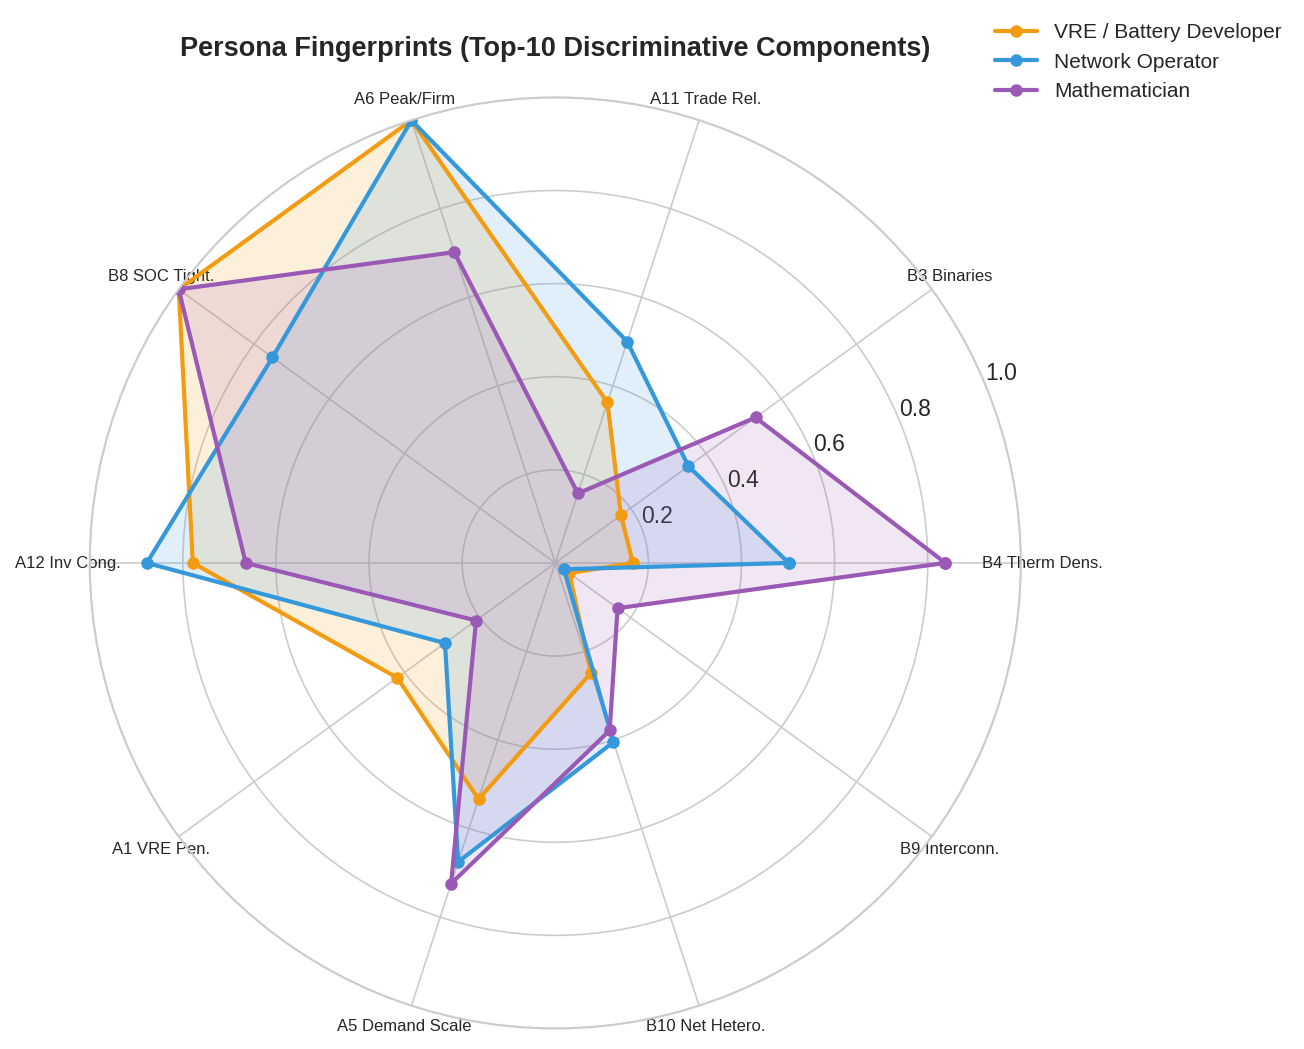

Most discriminative components (by cross-persona variance):
  1. B4 Therm Dens.        var=0.0751  (VRE / Ba=0.17, Network =0.50, Mathemat=0.84)
  2. B3 Binaries           var=0.0213  (VRE / Ba=0.17, Network =0.35, Mathemat=0.53)
  3. A11 Trade Rel.        var=0.0199  (VRE / Ba=0.36, Network =0.50, Mathemat=0.16)
  4. A6 Peak/Firm          var=0.0197  (VRE / Ba=1.00, Network =1.00, Mathemat=0.70)
  5. B8 SOC Tight.         var=0.0138  (VRE / Ba=1.00, Network =0.75, Mathemat=1.00)
  6. A12 Inv Cong.         var=0.0075  (VRE / Ba=0.78, Network =0.88, Mathemat=0.67)
  7. A1 VRE Pen.           var=0.0074  (VRE / Ba=0.42, Network =0.29, Mathemat=0.21)
  8. A5 Demand Scale       var=0.0065  (VRE / Ba=0.53, Network =0.68, Mathemat=0.72)
  9. B10 Net Hetero.       var=0.0047  (VRE / Ba=0.25, Network =0.40, Mathemat=0.38)
  10. B9 Interconn.         var=0.0041  (VRE / Ba=0.04, Network =0.02, Mathemat=0.17)


In [15]:
from matplotlib.patches import Patch

# Radar chart: top-10 most discriminative components
# Compute variance across personas for each component
comp_variance = []
for j, col in enumerate(all_norm_cols):
    persona_means = [persona_crit_dfs[pk][col].mean() for pk in PERSONA_CONFIG]
    comp_variance.append((j, np.var(persona_means)))
comp_variance.sort(key=lambda x: x[1], reverse=True)
top_indices = [idx for idx, _ in comp_variance[:10]]

radar_labels = [all_labels[i] for i in top_indices]
n_radar = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_radar, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for pk, pcfg in PERSONA_CONFIG.items():
    values = [persona_crit_dfs[pk][all_norm_cols[i]].mean() for i in top_indices]
    values += values[:1]
    ax.fill(angles, values, alpha=0.15, color=pcfg['color'])
    ax.plot(angles, values, 'o-', linewidth=2, markersize=5,
            color=pcfg['color'], label=pcfg['label'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Persona Fingerprints (Top-10 Discriminative Components)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_persona_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print('Most discriminative components (by cross-persona variance):')
for rank, (idx, var) in enumerate(comp_variance[:10], 1):
    means_str = ', '.join(f'{PERSONA_CONFIG[pk]["label"][:8]}={persona_crit_dfs[pk][all_norm_cols[idx]].mean():.2f}'
                          for pk in PERSONA_CONFIG)
    print(f'  {rank}. {all_labels[idx]:20s}  var={var:.4f}  ({means_str})')

## 11. Stress vs Hardness Scatter (All Personas)

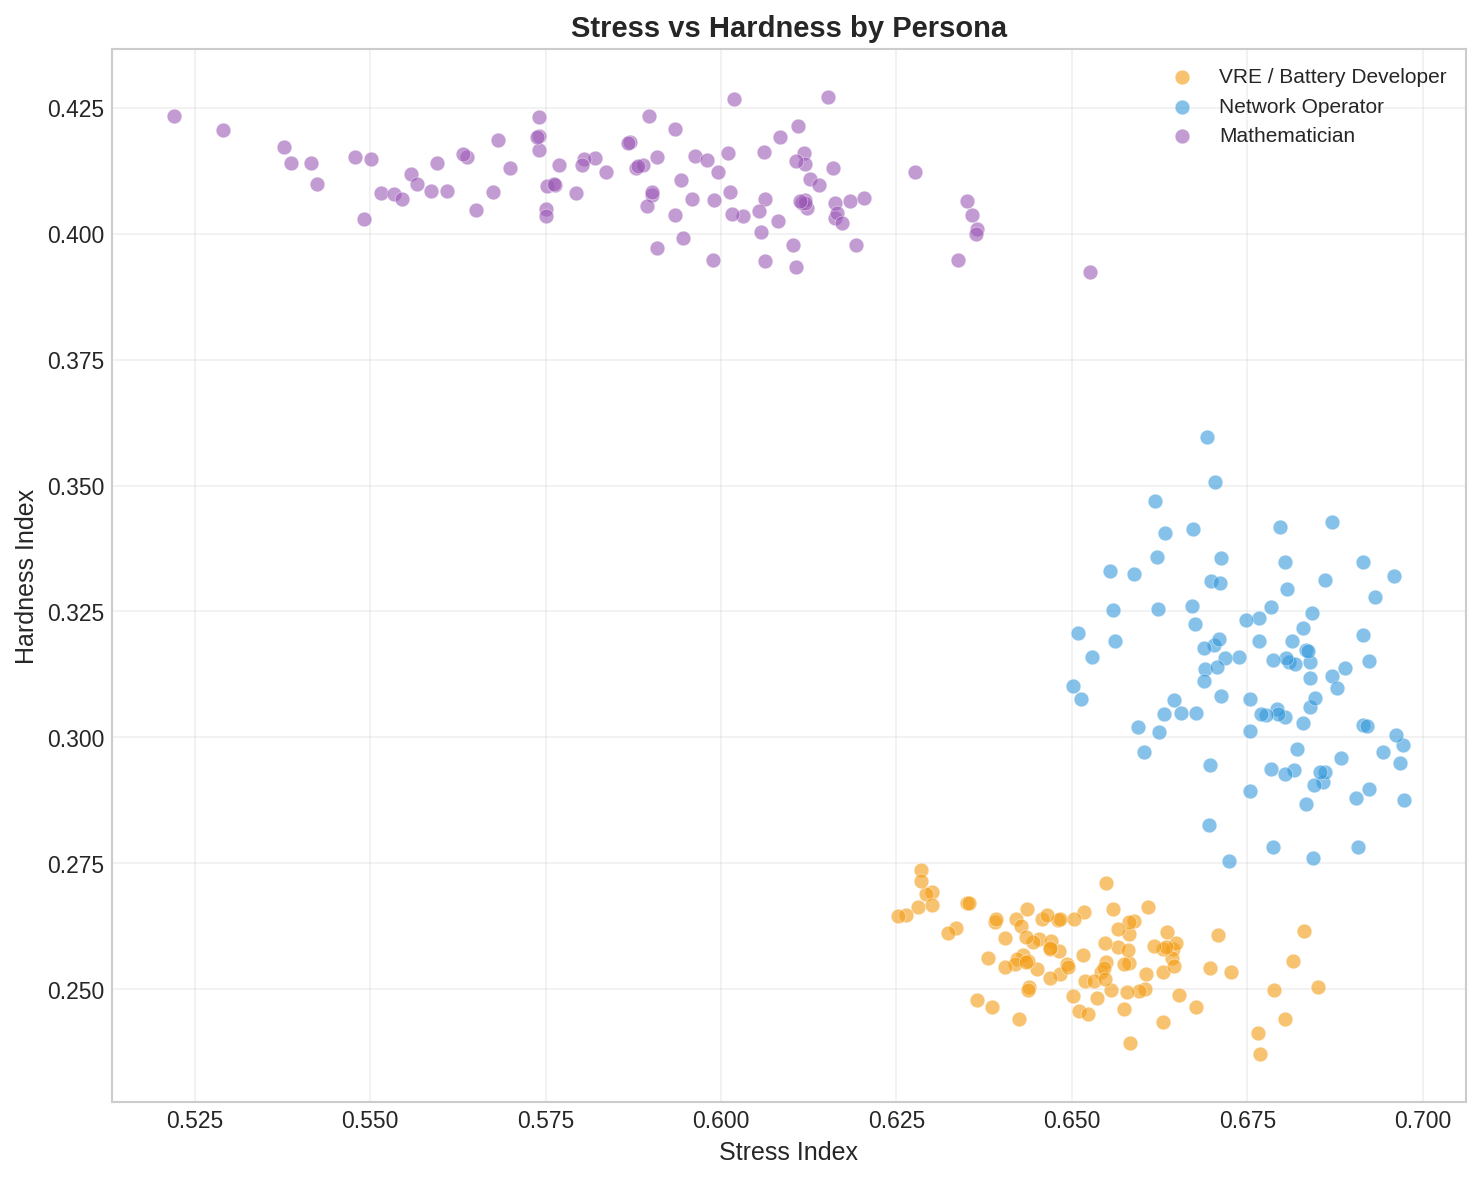

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

for pk, pcfg in PERSONA_CONFIG.items():
    df_c = persona_crit_dfs[pk]
    ax.scatter(df_c['stress_index'], df_c['hardness_index'],
              c=pcfg['color'], label=pcfg['label'],
              s=50, alpha=0.6, edgecolors='white', linewidth=0.3)

ax.set_xlabel('Stress Index', fontsize=12)
ax.set_ylabel('Hardness Index', fontsize=12)
ax.set_title('Stress vs Hardness by Persona', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_persona_stress_vs_hardness.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Correlation: Components vs Pipeline Performance (per Persona)

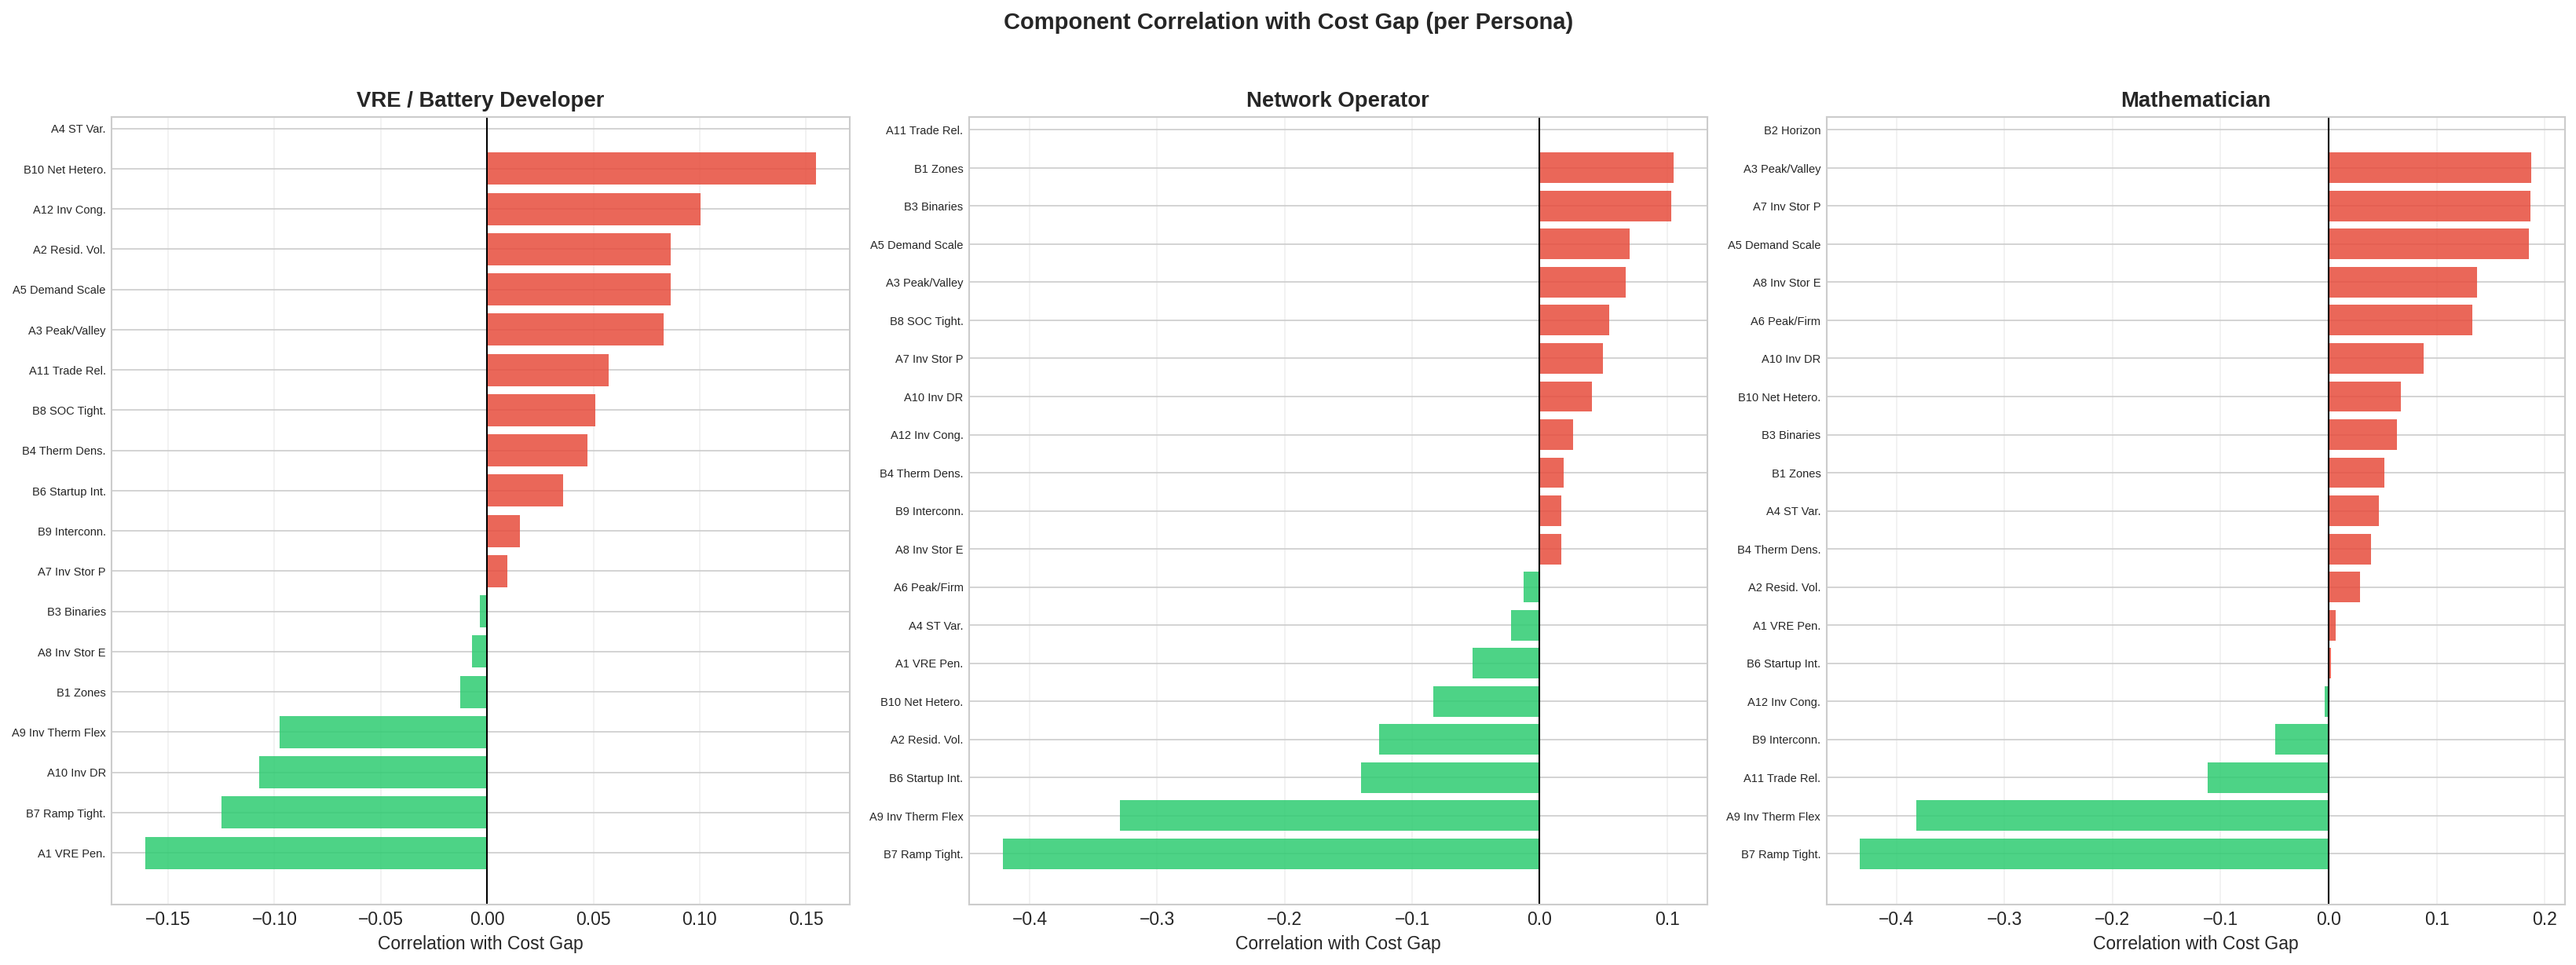

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (pk, pcfg) in zip(axes, PERSONA_CONFIG.items()):
    df_p = persona_dfs[pk]
    df_c = persona_crit_dfs[pk]
    df_m = df_p.merge(df_c, on='scenario_id', how='left', suffixes=('', '_crit'))

    corr_cols = [c for c in all_norm_cols if c in df_m.columns]
    corrs = df_m[corr_cols + ['cost_gap_pct']].corr()['cost_gap_pct'].drop('cost_gap_pct')
    sorted_corrs = corrs.sort_values()

    colors_c = ['#e74c3c' if v > 0 else '#2ecc71' for v in sorted_corrs.values]
    labels_c = [all_labels[all_norm_cols.index(c)] for c in sorted_corrs.index]
    ax.barh(labels_c, sorted_corrs.values, color=colors_c, alpha=0.85)
    ax.set_xlabel('Correlation with Cost Gap')
    ax.set_title(f'{pcfg["label"]}', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Component Correlation with Cost Gap (per Persona)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_persona_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Economic Advantage per Persona

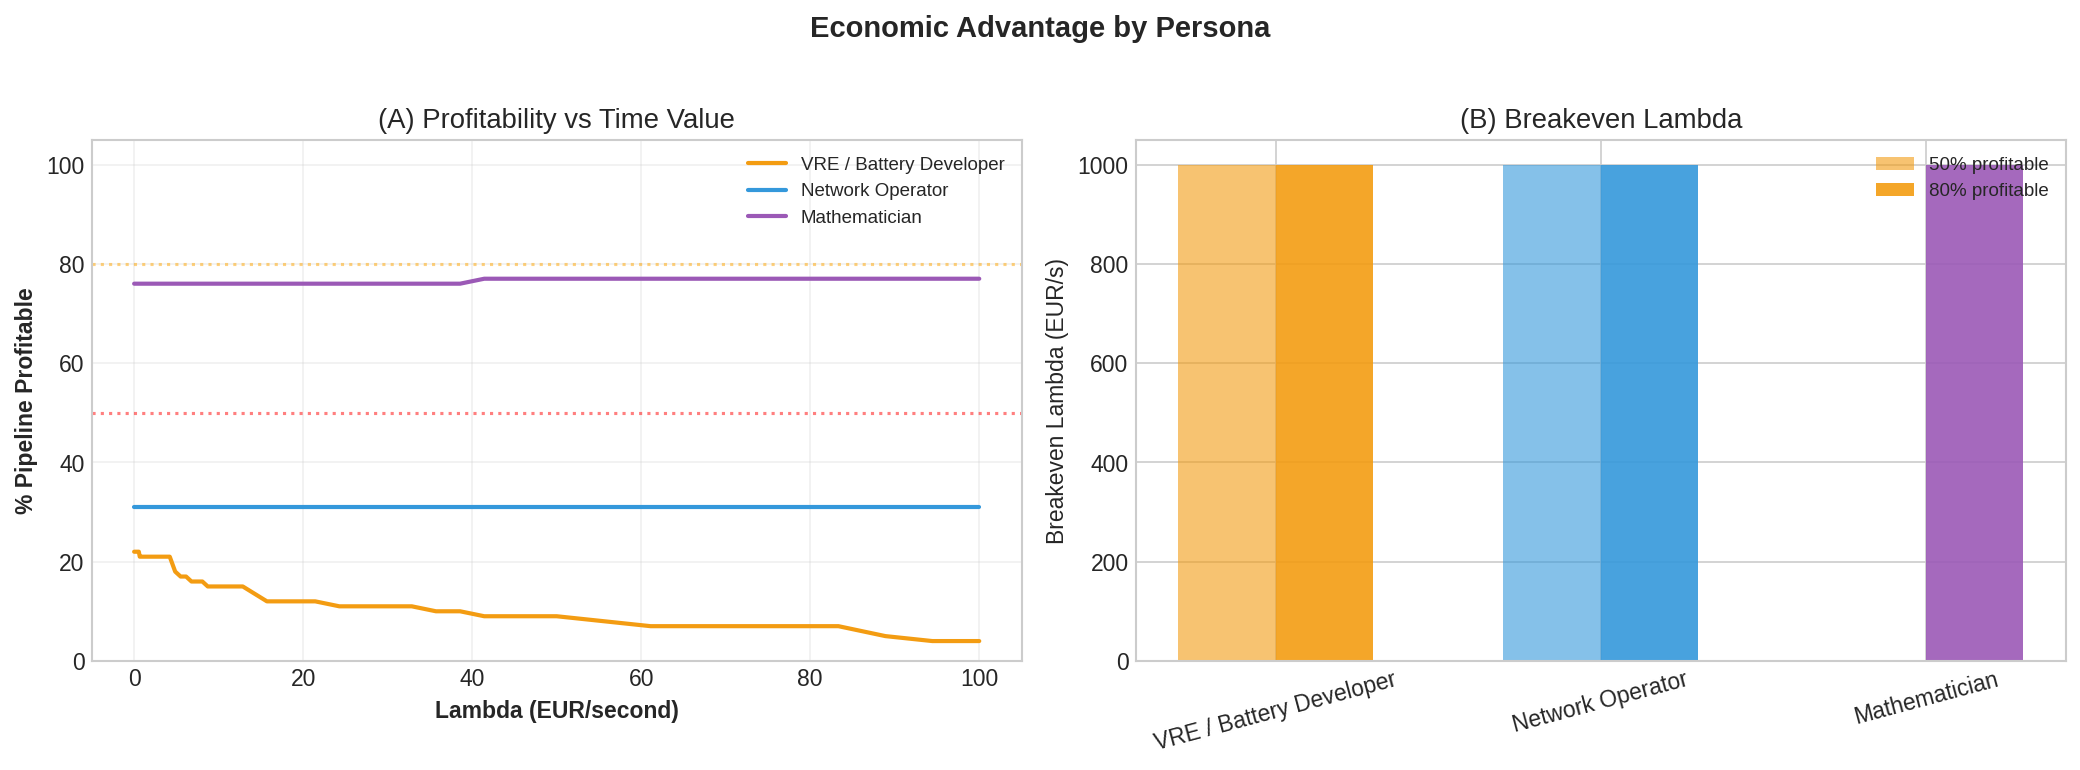


VRE / Battery Developer            : breakeven_50=1000.00, breakeven_80=1000.00 EUR/s

Network Operator                   : breakeven_50=1000.00, breakeven_80=1000.00 EUR/s

Mathematician                      : breakeven_50=0.00, breakeven_80=1000.00 EUR/s


In [18]:
from src.eval.economic_advantage import EconomicAdvantageAnalyzer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: % Profitable vs Lambda (per persona)
ax = axes[0]
for pk, pcfg in PERSONA_CONFIG.items():
    econ = EconomicAdvantageAnalyzer(persona_dfs[pk])
    sens = econ.sensitivity_analysis()
    ax.plot(sens['lambda'], sens['pct_profitable'], '-', lw=2,
            color=pcfg['color'], label=pcfg['label'])
ax.axhline(y=50, color='red', linestyle=':', alpha=0.5)
ax.axhline(y=80, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('% Pipeline Profitable', fontweight='bold')
ax.set_title('(A) Profitability vs Time Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# Panel B: Breakeven lambda comparison
ax = axes[1]
breakevens_50 = []
breakevens_80 = []
for pk in PERSONA_CONFIG:
    econ = EconomicAdvantageAnalyzer(persona_dfs[pk])
    summary = econ.compute_summary()
    breakevens_50.append(summary.get('breakeven_lambda_50pct', 1000))
    breakevens_80.append(summary.get('breakeven_lambda_80pct', 1000))

x_pos = np.arange(len(PERSONA_CONFIG))
ax.bar(x_pos - 0.15, breakevens_50, 0.3, label='50% profitable',
       color=[PERSONA_CONFIG[pk]['color'] for pk in PERSONA_CONFIG], alpha=0.6)
ax.bar(x_pos + 0.15, breakevens_80, 0.3, label='80% profitable',
       color=[PERSONA_CONFIG[pk]['color'] for pk in PERSONA_CONFIG], alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels([PERSONA_CONFIG[pk]['label'] for pk in PERSONA_CONFIG], rotation=15)
ax.set_ylabel('Breakeven Lambda (EUR/s)')
ax.set_title('(B) Breakeven Lambda')
ax.legend(fontsize=9)

fig.suptitle('Economic Advantage by Persona', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_persona_economic.png', dpi=300, bbox_inches='tight')
plt.show()

# Print breakeven summary
for pk, pcfg in PERSONA_CONFIG.items():
    econ = EconomicAdvantageAnalyzer(persona_dfs[pk])
    summary = econ.compute_summary(lambda_values=[1, 5, 10, 50])
    print(f'\n{pcfg["label"]:35s}: breakeven_50={summary["breakeven_lambda_50pct"]:.2f}, '
          f'breakeven_80={summary["breakeven_lambda_80pct"]:.2f} EUR/s')

## 14. Final Summary

In [19]:
print('=' * 90)
print('PERSONA-BASED EXTREME EVALUATION SUMMARY')
print('=' * 90)

summary_rows = []
for pk, pcfg in PERSONA_CONFIG.items():
    df_p = persona_dfs[pk]
    df_c = persona_crit_dfs[pk]
    valid = df_p.dropna(subset=['speedup', 'cost_gap_pct'])
    n_tl = (df_p['milp_termination'] == 'maxTimeLimit').sum()
    n_better = (valid['cost_gap_pct'] < 0).sum()

    row = {
        'Persona': pcfg['label'],
        'N': len(df_p),
        'TL%': f'{n_tl/max(len(df_p),1)*100:.0f}%',
        'Crit': f'{df_c["criticality_index"].mean():.3f}',
        'PipeTime': f'{df_p["pipeline_solve_time"].mean():.0f}s',
        'MILPTime': f'{df_p["milp_solve_time"].mean():.0f}s',
        'Speedup': f'{valid["speedup"].mean():.1f}x',
        'CostGapP50': f'{valid["cost_gap_pct"].median():.1f}%',
        'Better': f'{n_better}/{len(valid)}',
    }
    summary_rows.append(row)

    print(f'\n  {pcfg["label"]:35s} (n={len(df_p)}, MaxTL={n_tl})')
    print(f'    Criticality:   {df_c["criticality_index"].mean():.3f} '
          f'(stress={df_c["stress_index"].mean():.3f}, hard={df_c["hardness_index"].mean():.3f})')
    print(f'    Pipeline time:  mean={df_p["pipeline_solve_time"].mean():.1f}s')
    print(f'    MILP time:      mean={df_p["milp_solve_time"].mean():.1f}s')
    print(f'    Speedup:        mean={valid["speedup"].mean():.1f}x, median={valid["speedup"].median():.1f}x')
    print(f'    Cost gap:       P50={valid["cost_gap_pct"].median():.1f}%, '
          f'P90={np.percentile(valid["cost_gap_pct"], 90):.1f}%')
    print(f'    Pipeline better: {n_better}/{len(valid)} ({n_better/max(len(valid),1)*100:.0f}%)')
    print(f'    Stages: {dict(df_p["pipeline_stage"].value_counts())}')

# Save summary DataFrame
df_summary = pd.DataFrame(summary_rows)
print(f'\n{df_summary.to_string(index=False)}')
df.to_csv(OUTPUT_DIR / 'persona_full_comparison.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR / "persona_full_comparison.csv"}')
print('=' * 90)

PERSONA-BASED EXTREME EVALUATION SUMMARY

  VRE / Battery Developer             (n=100, MaxTL=0)
    Criticality:   0.454 (stress=0.652, hard=0.257)
    Pipeline time:  mean=155.0s
    MILP time:      mean=24.3s
    Speedup:        mean=0.2x, median=0.1x
    Cost gap:       P50=4.7%, P90=31.8%
    Pipeline better: 22/100 (22%)
    Stages: {'repair_20': np.int64(49), 'full_soft': np.int64(34), 'hard_fix': np.int64(17)}

  Network Operator                    (n=100, MaxTL=49)
    Criticality:   0.494 (stress=0.677, hard=0.312)
    Pipeline time:  mean=186.4s
    MILP time:      mean=703.6s
    Speedup:        mean=5.5x, median=4.3x
    Cost gap:       P50=30.0%, P90=148.3%
    Pipeline better: 31/100 (31%)
    Stages: {'hard_fix': np.int64(36), 'repair_20': np.int64(33), 'full_soft': np.int64(31)}

  Mathematician                       (n=100, MaxTL=28)
    Criticality:   0.500 (stress=0.590, hard=0.410)
    Pipeline time:  mean=318.3s
    MILP time:      mean=364.4s
    Speedup:        